# Algoritmos

## Gerando dados

In [1]:
from joblib import load, dump

In [2]:
import os
try:
    os.chdir("aulas_teoricas")
except FileNotFoundError:
    pass

os.listdir("./")

['00-divisão_dados_2026-07-14.ipynb',
 '01-aula-03_2026-07-14.ipynb',
 '02-aula-04_2026-07-14.ipynb',
 '03-aula-05_01-dados_2026-07-14.ipynb',
 '03-aula-05_02-cluster_2026-07-14.ipynb',
 '03-aula-05_03-classif_2026-07-14.ipynb',
 '03-aula-05_04-regressão_2026-07-14.ipynb',
 '03-aula-05_05_analise_2026-07-14.ipynb',
 '04-aula-06-divisão de dados_2026-07-14.ipynb',
 'data',
 'SMOTE.ipynb',
 'src',
 'ydata-profiling.ipynb']

In [3]:
df_1 = load('./data/05_aula_df_1')
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o


## k-means

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score

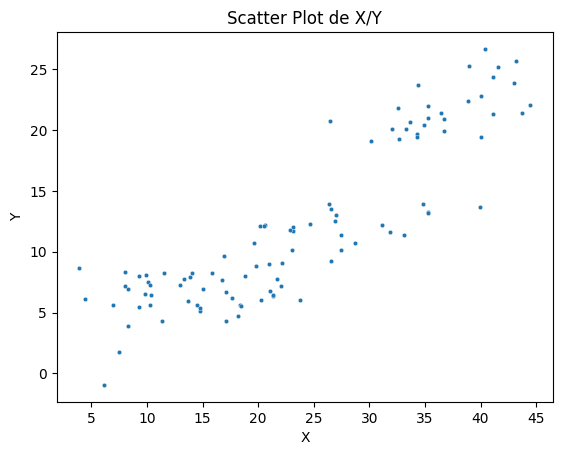

In [6]:
x = 'x_noise'
y = 'y_noise_new'
s = 10
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    data=df_1,
)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [7]:
def ponto_estrela(df_sample: pd.DataFrame, x: str, y: str) -> tuple:
    x_estrela = np.random.randint(
        np.min(df_sample[x]),
        np.max(df_sample[x]),
    )
    y_estrela = np.random.randint(
        np.min(df_sample[y]),
        np.max(df_sample[y]),
    )
    return x_estrela, y_estrela

def seta_estrela(
        df_sample: pd.DataFrame,
        x: str,
        y: str,
        color: str = 'g',
        seta: bool = False,
        n_setas: int = 5) -> None:
    sns.scatterplot(
        x=x,
        y=y,
        s=s,
        color='b',
        data=df_sample,
    )
    x_estrela, y_estrela = ponto_estrela(df_sample, x, y)
    plt.plot(
        x_estrela,
        y_estrela,
        '*' + color,
        markersize=15
    )
    if seta:
        for _ in range(n_setas):
            index = df_sample[x].sample(1).index[0]
            dx = df_sample[x][index] - x_estrela
            dy = df_sample[y][index] - y_estrela
            plt.arrow(
                x_estrela,
                y_estrela, 
                dx,
                dy,
                head_width=1,
                head_length=1,
                length_includes_head=True,
                color=color,
            )
    return None

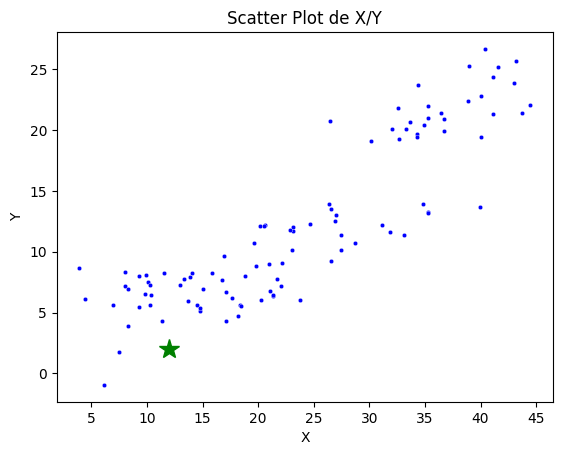

In [8]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new'
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

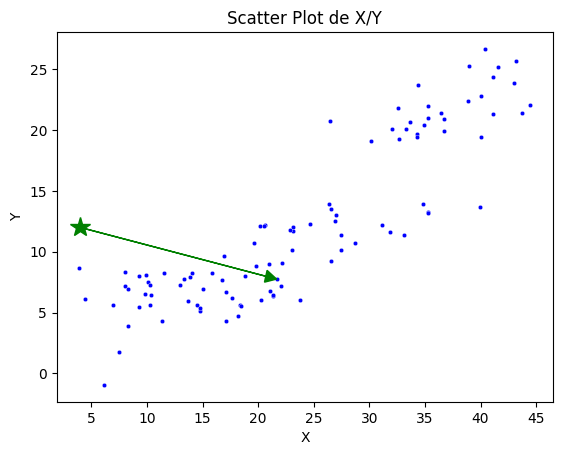

In [9]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'seta': True,
    'n_setas': 1
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

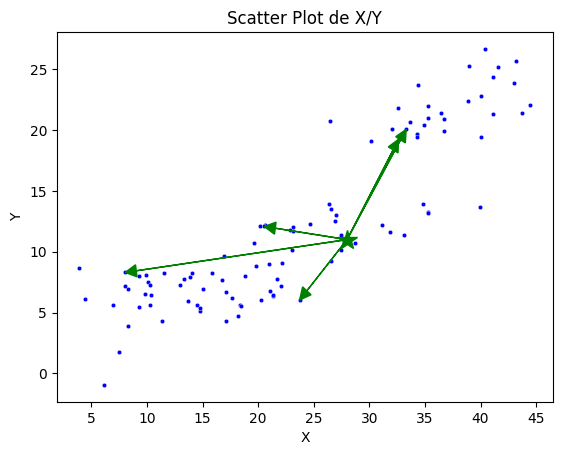

In [10]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'seta': True,
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

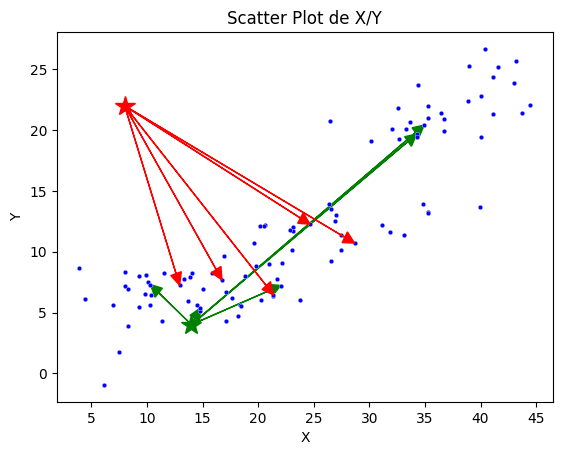

In [11]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'seta': True,
}
seta_estrela(**grafico)
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'color': 'r',
    'seta': True,
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [12]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_1[[x, y]])
scaled_features[:5]

array([[ 1.57364483,  1.8314633 ],
       [-1.2540686 , -0.61485802],
       [ 1.17634214,  1.16564535],
       [-0.94268406, -0.66318093],
       [-0.54677913, -0.89144423]])

In [13]:
df_1[x+'_scaled'] = scaled_features[:, 0]
df_1[y+'_scaled'] = scaled_features[:, 1]
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_scaled,y_noise_new_scaled
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,1.573645,1.831463
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,-1.254069,-0.614858
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,1.176342,1.165645
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,-0.942684,-0.663181
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,-0.546779,-0.891444


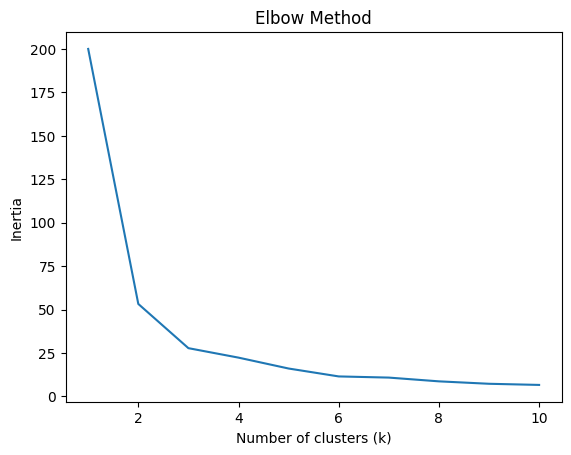

In [14]:
x_scaled = 'x_noise_scaled'
y_scaled = 'y_noise_new_scaled'
inertia = []
for i in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df_1[[x_scaled, y_scaled]])
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [15]:

# Inicializar uma lista vazia que vai conter os valores da silueta média
siluetas = []
# Este é o número máximo de grupos que vamos testar
max_clusters = 10

# O loop percorre de 2 até o máximo de clusters
for n_clusters in range(2, max_clusters+1):
    # Aqui rodamos o k-means
    km = KMeans(n_clusters=n_clusters).fit(df_1[[x_scaled, y_scaled]])
    # Aqui calculamos a silueta e guardamos o resultado na lista 'siluetas'
    siluetas.append(silhouette_score(df_1[[x_scaled, y_scaled]], km.labels_))
siluetas[:5]

[0.6123335974505002,
 0.5371422175305763,
 0.47621398826104444,
 0.44312112452426433,
 0.41037375921409536]

In [16]:
df_silueta = pd.DataFrame({'n_clusters': list(range(2, max_clusters+1)), 'silhueta_média': siluetas})
df_silueta

,n_clusters,silhueta_média
0,2,0.612334
1,3,0.537142
2,4,0.476214
3,5,0.443121
4,6,0.410374
5,7,0.400571
6,8,0.404833
7,9,0.417379
8,10,0.390231


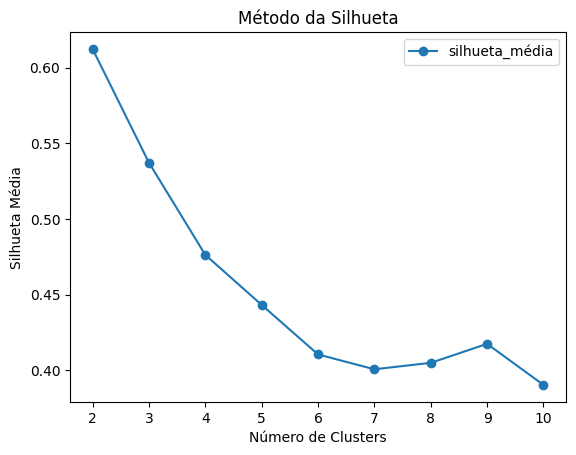

In [17]:
df_silueta.plot.line(
    x='n_clusters',
    y='silhueta_média',
    marker='o'
)
plt.title('Método da Silhueta')
plt.ylabel('Silhueta Média')
plt.xlabel('Número de Clusters')
plt.show()

In [18]:
optimal_k = df_silueta[df_silueta['silhueta_média'] == df_silueta['silhueta_média'].max()]['n_clusters'].values[0]
optimal_k

2

In [19]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans.fit(scaled_features)

KMeans(n_clusters=2, random_state=42)

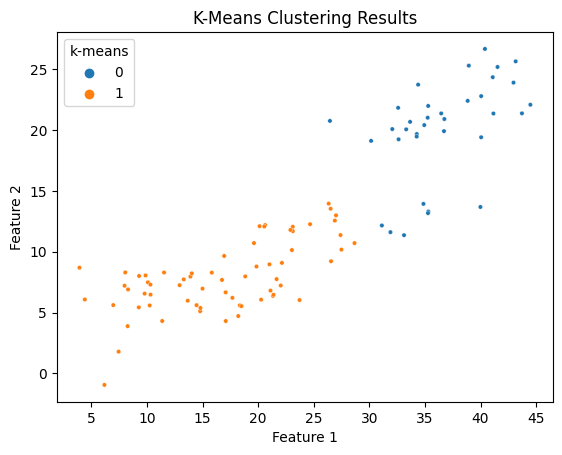

In [20]:
df_1['k-means'] = [1 if i == 0 else 0 for i in kmeans.labels_]
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='k-means',
    data=df_1
)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering Results')
plt.show()

In [21]:
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_scaled,y_noise_new_scaled,k-means
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,1.573645,1.831463,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,-1.254069,-0.614858,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,1.176342,1.165645,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,-0.942684,-0.663181,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,-0.546779,-0.891444,1


In [22]:
def calcular_metricas(x: str, y: str, target: str, df: pd.DataFrame) -> None:
    '''
        Função para calcular métricas de avaliação de clustering.
            Parametros:
                x: str -> coluna que representa a primeira dimensão dos dados
                y: str -> coluna que representa a segunda dimensão dos dados
                target: str -> coluna que representa os rótulos dos clusters
                df: pd.DataFrame -> DataFrame contendo os dados
            Retorna:
                None -> apenas imprime as métricas calculadas
    '''
    print(f"Calculando métricas para o target: {target}\n")
    # Calcula a métrica de Silhouette 
    ss = round(silhouette_score(df[[x, y]], df[target]), 3)
    print(f"Silhouette Score -> {ss}")

    # Calcula a métrica de Calinski-Harabasz
    chs = round(calinski_harabasz_score(df[[x, y]], df[target]), 3)
    print(f"Calinski Harabasz Score -> {chs}")

    # Calcula a métrica de Davies-Bouldin
    dbs = round(davies_bouldin_score(df[[x, y]], df[target]), 3)
    print(f"Davies Bouldin Score -> {dbs}")

    # adjusted_rand_score(
    #     dados['x'],
    #     dados['x_noise_mean'],
    # )

    # adjusted_mutual_info_score(
    #     dados['x'],
    #     dados['x_noise_mean'],
    # )
    return None

In [23]:
metricas = {
    'x': x_scaled,
    'y': y_scaled,
    'target': 'k-means',
    'df': df_1
}
calcular_metricas(**metricas)

Calculando métricas para o target: k-means

Silhouette Score -> 0.62
Calinski Harabasz Score -> 270.218
Davies Bouldin Score -> 0.503


## DBSCAM

In [24]:
from sklearn.cluster import DBSCAN

In [25]:
# Create a DBSCAN instance with specified parameters
min_samples = [1, 2, 3, 4, 5, 6]
eps = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5]

for sample in min_samples:
    for ep in eps:
        db = DBSCAN(eps=ep, min_samples=sample)
        # Fit the model to the data and predict cluster labels
        clusters = db.fit_predict(df_1[[x_scaled, y_scaled]])
        cluster, num = np.unique(clusters, return_counts=True)
        if len(cluster) == 2 or len(cluster) == 3:
            print("-----"*20)
            print(f"DBSCAN with eps={ep} and min_samples={sample}")
            print(cluster, num)

----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.5 and min_samples=1
[0 1] [28 72]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.4 and min_samples=2
[-1  0  1] [ 3 27 70]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.5 and min_samples=2
[0 1] [28 72]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.4 and min_samples=3
[-1  0  1] [ 3 27 70]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.5 and min_samples=3
[0 1] [28 72]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.1 and min_samples=4
[-1  0  1] [92  4  4]
----------------------------------------------------------

In [26]:
db = DBSCAN(eps=0.3, min_samples=4)
# Fit the model to the data and predict cluster labels
df_1['DBSCAN_1'] = db.fit_predict(df_1[[x_scaled, y_scaled]])

db = DBSCAN(eps=0.5, min_samples=3)
# Fit the model to the data and predict cluster labels
df_1['DBSCAN_2'] = db.fit_predict(df_1[[x_scaled, y_scaled]])
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_scaled,y_noise_new_scaled,k-means,DBSCAN_1,DBSCAN_2
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,1.573645,1.831463,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,-1.254069,-0.614858,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,1.176342,1.165645,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,-0.942684,-0.663181,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,-0.546779,-0.891444,1,1,1


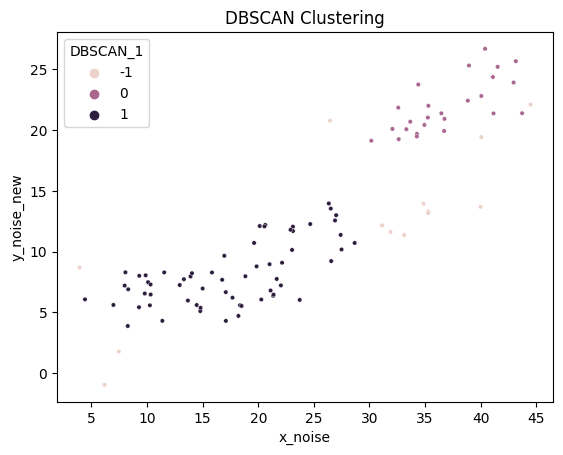

In [27]:
# Visualize the results
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='DBSCAN_1',
    data=df_1
)
plt.title("DBSCAN Clustering")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

In [28]:
metricas = {
    'x': x_scaled,
    'y': y_scaled,
    'target': 'DBSCAN_1',
    'df': df_1
}
calcular_metricas(**metricas)

Calculando métricas para o target: DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402


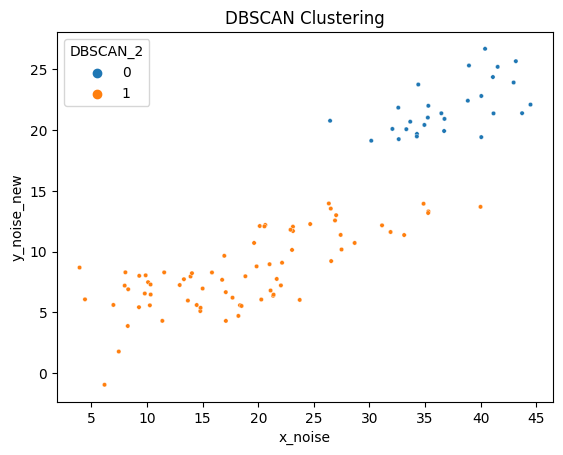

In [29]:
# Visualize the results
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='DBSCAN_2',
    data=df_1
)
plt.title("DBSCAN Clustering")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

In [30]:
metricas = {
    'x': x_scaled,
    'y': y_scaled,
    'target': 'DBSCAN_2',
    'df': df_1
}
calcular_metricas(**metricas)

Calculando métricas para o target: DBSCAN_2

Silhouette Score -> 0.61
Calinski Harabasz Score -> 217.816
Davies Bouldin Score -> 0.466


## Redes Neurais

In [31]:
import tensorflow as tf
from tensorflow import keras

2026-07-17 15:02:34.450193: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-17 15:02:34.451820: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-17 15:02:34.482081: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-17 15:02:34.483024: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are us

In [32]:
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_scaled,y_noise_new_scaled,k-means,DBSCAN_1,DBSCAN_2
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,1.573645,1.831463,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,-1.254069,-0.614858,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,1.176342,1.165645,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,-0.942684,-0.663181,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,-0.546779,-0.891444,1,1,1


In [33]:
# Sample data
data = df_1[[
    'x',
    'y',
    'x_noise',
    'y_noise',
    'y_noise_new',
    'x_noise_mean',
    'y_noise_mean',
    'x_noise_scaled',
    'y_noise_new_scaled',
]]

# Build an autoencoder
input_dim = data.shape[1]
encoding_dim = 2 # Reduced dimension for clustering
input_dim

9

In [34]:
input_layer = keras.layers.Input(shape=(input_dim,))
encoder = keras.layers.Dense(encoding_dim, activation='relu')(input_layer)
decoder = keras.layers.Dense(input_dim, activation='sigmoid')(encoder)

autoencoder = keras.Model(inputs=input_layer, outputs=decoder)
encoder_model = keras.Model(inputs=input_layer, outputs=encoder)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 9)]               0         
                                                                 
 dense (Dense)               (None, 2)                 20        
                                                                 
 dense_1 (Dense)             (None, 9)                 27        
                                                                 
Total params: 47
Trainable params: 47
Non-trainable params: 0
_________________________________________________________________


In [35]:
autoencoder.fit(data, data, epochs=50, batch_size=32)

Epoch 1/50
4/4 [==============================] - 0s 5ms/step - loss: 279.9476
Epoch 2/50
4/4 [==============================] - 0s 3ms/step - loss: 279.8158
Epoch 3/50
4/4 [==============================] - 0s 3ms/step - loss: 279.6819
Epoch 4/50
4/4 [==============================] - 0s 3ms/step - loss: 279.5566
Epoch 5/50
4/4 [==============================] - 0s 3ms/step - loss: 279.4439
Epoch 6/50
4/4 [==============================] - 0s 3ms/step - loss: 279.3193
Epoch 7/50
4/4 [==============================] - 0s 3ms/step - loss: 279.2126
Epoch 8/50
4/4 [==============================] - 0s 3ms/step - loss: 279.0978
Epoch 9/50
4/4 [==============================] - 0s 3ms/step - loss: 278.9775
Epoch 10/50
4/4 [==============================] - 0s 3ms/step - loss: 278.8610
Epoch 11/50
4/4 [==============================] - 0s 3ms/step - loss: 278.7418
Epoch 12/50
4/4 [==============================] - 0s 3ms/step - loss: 278.6325
Epoch 13/50
4/4 [==============================] 

In [36]:
# Get the encoded representation
encoded_data = encoder_model.predict(data)
encoded_data[:3]

4/4 [==============================] - 0s 2ms/step


array([[0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32)

In [37]:
for i in df_1.columns[-3:]:
    metricas = {
        'x': x_scaled,
        'y': y_scaled,
        'target': i,
        'df': df_1
    }
    calcular_metricas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Silhouette Score -> 0.62
Calinski Harabasz Score -> 270.218
Davies Bouldin Score -> 0.503
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Silhouette Score -> 0.61
Calinski Harabasz Score -> 217.816
Davies Bouldin Score -> 0.466
----------------------------------------------------------------------------------------------------


In [38]:
db = DBSCAN(eps=0.3, min_samples=4)
# Fit the model to the data and predict cluster labels
clusters = db.fit_predict(df_1[[x_scaled, y_scaled]])
df_1['NN-DBSCAN_1'] = clusters
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_scaled,y_noise_new_scaled,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,1.573645,1.831463,0,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,-1.254069,-0.614858,1,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,1.176342,1.165645,0,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,-0.942684,-0.663181,1,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,-0.546779,-0.891444,1,1,1,1


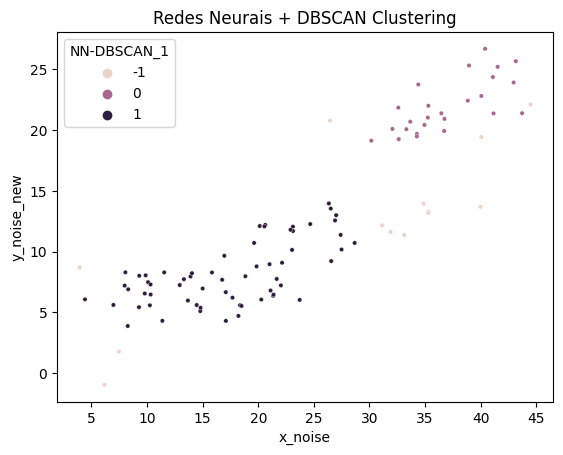

In [52]:
# Visualize the results
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='NN-DBSCAN_1',
    data=df_1
)
plt.title("Redes Neurais + DBSCAN Clustering")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

In [ ]:
# dump(df_1, './data/05_aula_df_3')

['./data/05_aula_df_3']

In [41]:
df_1 = load('./data/05_aula_df_3')
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_scaled,y_noise_new_scaled,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,1.573645,1.831463,0,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,-1.254069,-0.614858,1,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,1.176342,1.165645,0,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,-0.942684,-0.663181,1,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,-0.546779,-0.891444,1,1,1,1


In [42]:
for i in df_1.columns[-4:]:
    metricas = {
        'x': x_scaled,
        'y': y_scaled,
        'target': i,
        'df': df_1
    }
    calcular_metricas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Silhouette Score -> 0.62
Calinski Harabasz Score -> 270.218
Davies Bouldin Score -> 0.503
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Silhouette Score -> 0.61
Calinski Harabasz Score -> 217.816
Davies Bouldin Score -> 0.466
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: NN-DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402
----------------------------------------------------------------------------------------------------


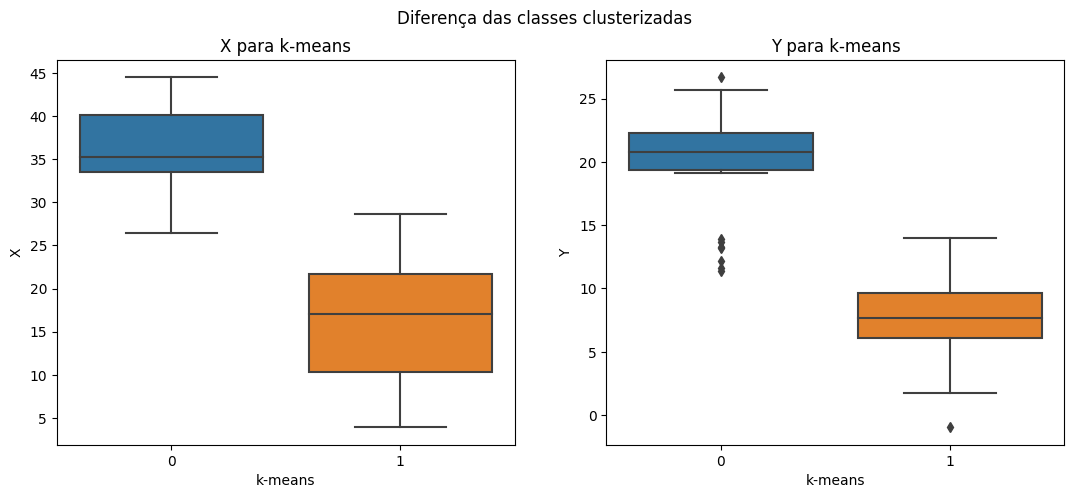

In [43]:
x_cluster = 'k-means'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

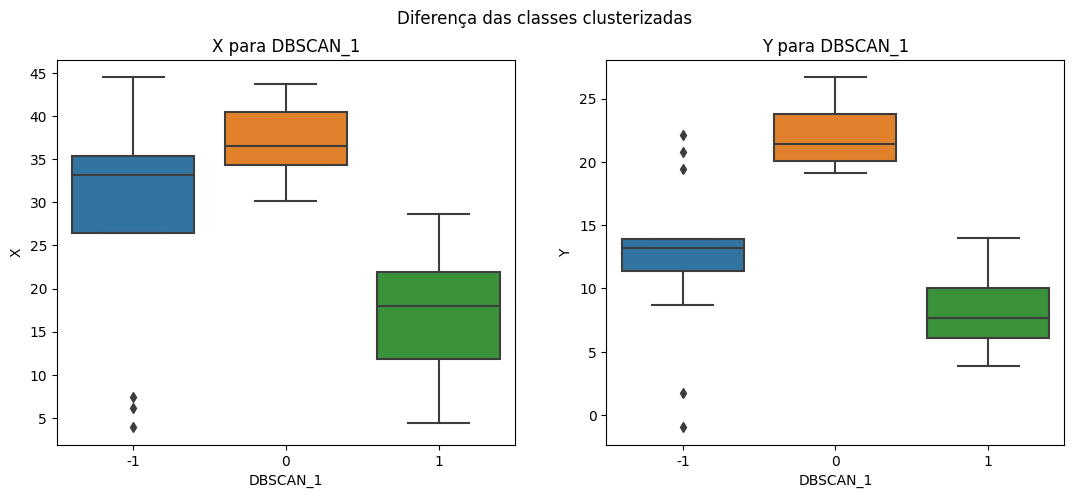

In [44]:
x_cluster = 'DBSCAN_1'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

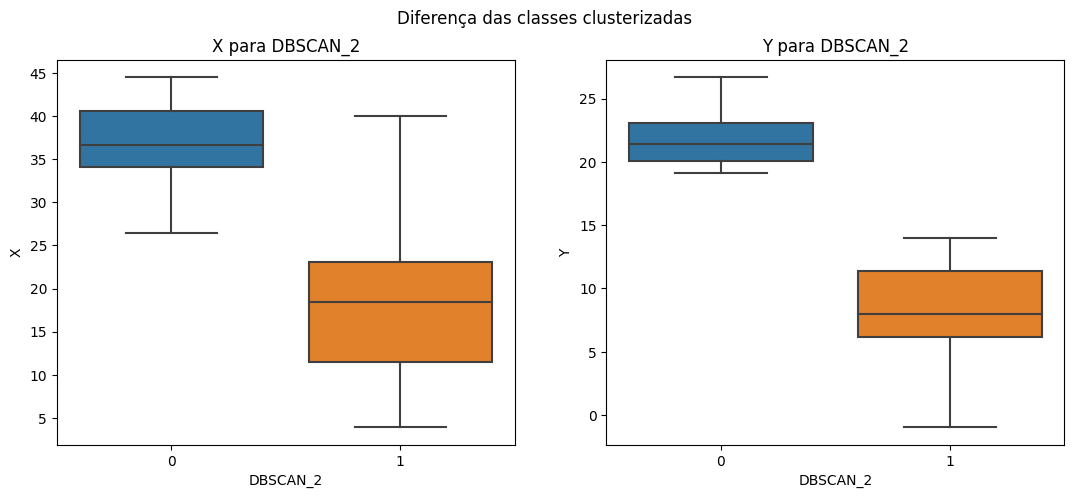

In [45]:
x_cluster = 'DBSCAN_2'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

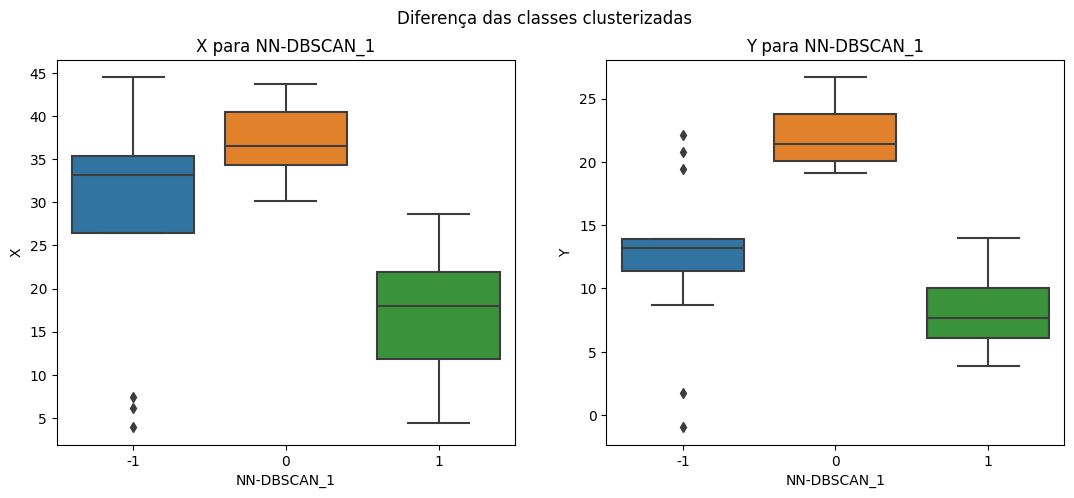

In [46]:
x_cluster = 'NN-DBSCAN_1'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

In [47]:
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_scaled,y_noise_new_scaled,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,1.573645,1.831463,0,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,-1.254069,-0.614858,1,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,1.176342,1.165645,0,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,-0.942684,-0.663181,1,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,-0.546779,-0.891444,1,1,1,1


In [48]:
def calcular_metricas_ajustadas(pred: str, df: pd.DataFrame, obsr: str = 'DBSCAN_1') -> None:
    print(f"Calculando métricas para o target: {pred}\n")
    # Calcula a métrica de Adjusted Rand Score
    ari = round(adjusted_rand_score(df[obsr], df[pred]), 3)
    print(f"Adjusted Rand Score -> {ari}")

    # Calcula a métrica de Adjusted Mutual Info Score
    ami = round(adjusted_mutual_info_score(df[obsr], df[pred]), 3)
    print(f"Adjusted Mutual Info Score -> {ami}")

    return None

In [51]:
for i in df_1.columns[-4:]:
    metricas = {
        'pred': i,
        'df': df_1
    }
    calcular_metricas_ajustadas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Adjusted Rand Score -> 0.813
Adjusted Mutual Info Score -> 0.739
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Adjusted Rand Score -> 1.0
Adjusted Mutual Info Score -> 1.0
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Adjusted Rand Score -> 0.712
Adjusted Mutual Info Score -> 0.692
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: NN-DBSCAN_1

Adjusted Rand Score -> 1.0
Adjusted Mutual Info Score -> 1.0
----------------------------------------------------------------------------------------------------


In [54]:
for i in df_1.columns[-4:]:
    metricas = {
        'pred': i,
        'obsr': 'k-means',
        'df': df_1
    }
    calcular_metricas_ajustadas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Adjusted Rand Score -> 1.0
Adjusted Mutual Info Score -> 1.0
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Adjusted Rand Score -> 0.813
Adjusted Mutual Info Score -> 0.739
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Adjusted Rand Score -> 0.733
Adjusted Mutual Info Score -> 0.671
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: NN-DBSCAN_1

Adjusted Rand Score -> 0.813
Adjusted Mutual Info Score -> 0.739
----------------------------------------------------------------------------------------------------
